In [ ]:
import geopandas as gpd
import pandas as pd
import os
import numpy as np
import contextily as ctx

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from IPython.display import Image
from skimage.morphology import (
    binary_closing,
    binary_erosion,
    binary_dilation,
    remove_small_objects,
    remove_small_holes,
    disk
)
from shapely.geometry import box
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio import Affine
from rasterio.crs import CRS
#import rasterio.transform
from rasterio.windows import from_bounds
from rasterio.warp import Resampling, reproject, transform
from datetime import datetime

In [ ]:
polygons_df = gpd.read_file("./polygons_stats.shp")
points_df = gpd.read_file("./points_stats.shp")


In [ ]:
tiff_path = "./ndvi_dif.tif"

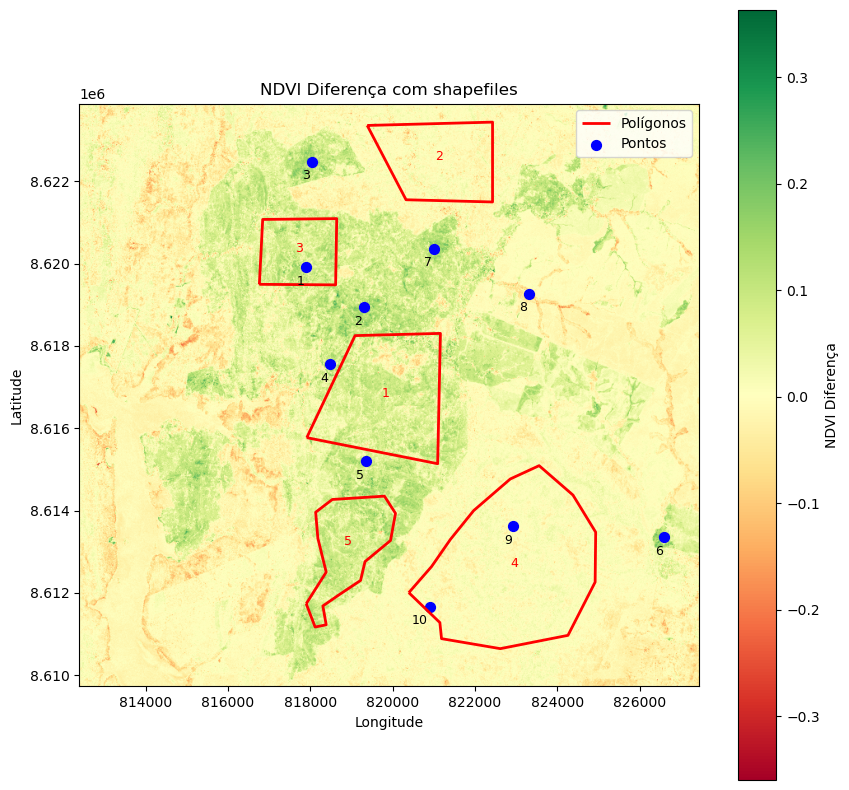

In [ ]:
with rasterio.open(tiff_path) as src:
    raster = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    # Reprojetar shapefiles para o CRS do raster, se necessário
    if points_df.crs != src.crs:
        points_df = points_df.to_crs(src.crs)
    if polygons_df.crs != src.crs:
        polygons_df = polygons_df.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(raster, cmap='RdYlGn', extent=extent)

polygons_df.boundary.plot(ax=ax, edgecolor='red', linewidth=2, label='Polígonos')
points_df.plot(ax=ax, color='blue', markersize=50, label='Pontos')

# Ajustar limites dos eixos
xmin = min(points_df.total_bounds[0], polygons_df.total_bounds[0], src.bounds.left)
xmax = max(points_df.total_bounds[2], polygons_df.total_bounds[2], src.bounds.right)
ymin = min(points_df.total_bounds[1], polygons_df.total_bounds[1], src.bounds.bottom)
ymax = max(points_df.total_bounds[3], polygons_df.total_bounds[3], src.bounds.top)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

for idx, row in points_df.iterrows():
    x, y = row.geometry.x * 0.99995, row.geometry.y * 0.99995 # reduzi um pouco o valor da coordenada para visualizar melhor o numero
    ax.text(x, y, str(row['id']), fontsize=9, color='black', ha='right')

for idx, row in polygons_df.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, str(row['id']), fontsize=9, color='red', ha='center')
    
ax.set_title("NDVI Diferença com shapefiles")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.colorbar(im, ax=ax, label="NDVI Diferença")

In [ ]:
print("Dataframe dos pontos:")
points_df

Dataframe dos pontos:


,id,SAMPLE_1,geometry
0,1,0.104911,POINT (-48.07569 -12.46826)
1,2,0.125563,POINT (-48.06271 -12.47687)
2,3,0.133191,POINT (-48.07471 -12.4451)
3,4,0.058556,POINT (-48.07016 -12.48943)
4,5,0.076985,POINT (-48.06198 -12.51067)
5,6,0.166851,POINT (-47.9951 -12.52657)
6,7,0.127892,POINT (-48.04733 -12.46387)
7,8,-0.058756,POINT (-48.02588 -12.47352)
8,9,0.009475,POINT (-48.02882 -12.52452)
9,10,-0.009710,POINT (-48.04732 -12.54241)


In [ ]:
print("Dataframe dos polígonos:")
polygons_df

Dataframe dos polígonos:


,id,_count,_sum,_mean,_min,_max,geometry
0,1,18984.0,1074.833366,0.056618,-0.161706,0.234902,"POLYGON ((-48.0459 -12.51106, -48.07519 -12.50..."
1,2,12047.0,-63.863439,-0.005301,-0.177967,0.267334,"POLYGON ((-48.05362 -12.45323, -48.06247 -12.4..."
2,3,7281.0,544.321747,0.074759,-0.105199,0.214813,"POLYGON ((-48.08557 -12.4579, -48.06904 -12.45..."
3,4,33263.0,55.213542,0.001660,-0.119699,0.065662,"POLYGON ((-48.0446 -12.54943, -48.04501 -12.54..."
4,5,8878.0,701.124280,0.078973,-0.149098,0.232128,"POLYGON ((-48.06934 -12.51916, -48.05771 -12.5..."
